# Predicting Heart Disease Using Machine Learning

## 0. Executive Summary

**Project Goal:** Develop a machine learning model capable of predicting heart disease presence with over 90% accuracy using clinical parameters (age, sex, chest pain, etc.).

**Key Achievements:**
* **Champion Model:** Logistic Regression achieved a **90.16% test accuracy** and a **85.46% Cross-Validated accuracy**.
* **Feature Engineering:** Implemented One-Hot Encoding for categorical features, which resulted in a significant performance boost over the baseline models.
* **Risk-Aware Evaluation:** Adjusted classification thresholds to prioritize **Recall (90.6%)**, ensuring the model identifies as many high-risk patients as possible—a critical requirement in medical diagnostics.
* **Algorithm Comparison:** Evaluated multiple architectures including Random Forest, XGBoost, and CatBoost, concluding that a well-tuned linear model provided the best generalization for this dataset size.

**Top Clinical Indicators:**
The analysis revealed that **Chest Pain Type (`cp`)**, **Number of Major Vessels (`ca`)**, and **Thalassemia (`thal`)** are the strongest predictors of heart disease risk.

## 1. Problem Definition
**Objective:** To leverage clinical parameters—ranging from blood pressure and cholesterol levels to specific electrocardiogram results—to develop a predictive model that identifies the presence of heart disease. This project serves as a proof-of-concept for how machine learning can assist medical professionals in early-stage diagnosis and risk assessment.

## 2. Data
The dataset utilized in this study is the Cleveland Heart Disease database (available via the UCI Machine Learning Repository and Kaggle). While the original database contains 76 attributes, this research focuses on the 14 primary clinical indicators widely recognized by cardiologists as significant predictors of cardiac health.

* Dataset Size: 303 instances.
* Key Variables: 13 independent features (clinical measurements) and 1 dependent target variable (disease presence).

## 3. Evaluation
**Success Criteria:** Our initial benchmark for project viability is 95% accuracy. However, given the medical nature of this application, we will also optimize for Recall (minimizing False Negatives) and AUC-ROC, ensuring the model is not only accurate but safe for clinical decision support.

## 4. Features
| Feature | Description | Example Values |
| :--- | :--- | :--- |
| **age** | Age in years | 29, 45, 60 |
| **sex** | 1 = male; 0 = female | 0, 1 |
| **cp** | **Chest pain type:**<br>0: Typical angina<br>1: Atypical angina<br>2: Non-anginal pain<br>3: Asymptomatic | 0, 1, 2, 3 |
| **trestbps** | Resting blood pressure (in mm Hg) | 120, 140, 150 |
| **chol** | Serum cholesterol in mg/dl | 180, 220, 250 |
| **fbs** | Fasting blood sugar > 120 mg/dl (1 = true; 0 = false) | 0, 1 |
| **restecg** | **Resting ECG results:**<br>0: Normal<br>1: ST-T Wave abnormality<br>2: Left ventricular hypertrophy | 0, 1, 2 |
| **thalach** | Maximum heart rate achieved | 160, 180, 190 |
| **exang** | Exercise induced angina (1 = yes; 0 = no) | 0, 1 |
| **oldpeak** | ST depression induced by exercise relative to rest | 0.5, 1.0, 2.0 |
| **slope** | **Slope of the peak exercise ST segment:**<br>0: Upsloping, 1: Flatsloping, 2: Downsloping | 0, 1, 2 |
| **ca** | Number of major vessels (0-3) colored by fluoroscopy | 0, 1, 2, 3 |
| **thal** | **Thalium stress result:**<br>1, 3: Normal<br>6: Fixed defect<br>7: Reversible defect | 1, 3, 6, 7 |
| **target** | Have disease or not (1 = yes; 0 = no) | 0, 1 |

*Note: Features such as `cp` (chest pain type) and `thal` (thalassemia) are categorical and require specific preprocessing (e.g., One-Hot Encoding) to ensure the model correctly interprets the non-ordinal relationship between their values.*

## 5. Tools & Technologies
* **Data Manipulation:** `Pandas`, `NumPy`
* **Visualization:** `Matplotlib`, `Seaborn`
* **Machine Learning:** `Scikit-Learn`, `XGBoost`
* **Evaluation:** `Classification Report`, `Confusion Matrix`, `ROC Curve`

### 5.1 Preparing the tools

In [1]:
# Import all the tools we need

# Regular EDA (Exploratory Data Analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# We want our plots to appear inside the notebook
%matplotlib inline 

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

### 5.2 Import the data

In [2]:
df = pd.read_csv("heart-disease.csv")

## 1. Data Exploration (exploratory data analysis or EDA)

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a professional visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

In [4]:
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

**Insight:** The dataset is relatively balanced, with a slight majority of patients having heart disease (165) compared to those who do not (138). This balance ensures that our model won't be inherently biased toward one outcome, allowing for more reliable accuracy and recall metrics.

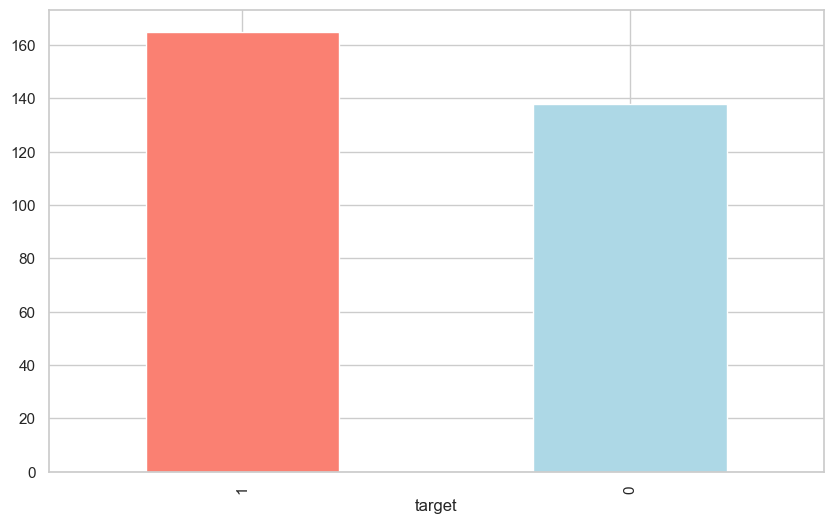

In [5]:
df["target"].value_counts().plot(kind="bar", color=["salmon", "lightblue"]);

### 1.1 Heart Disease Frequency according to Sex

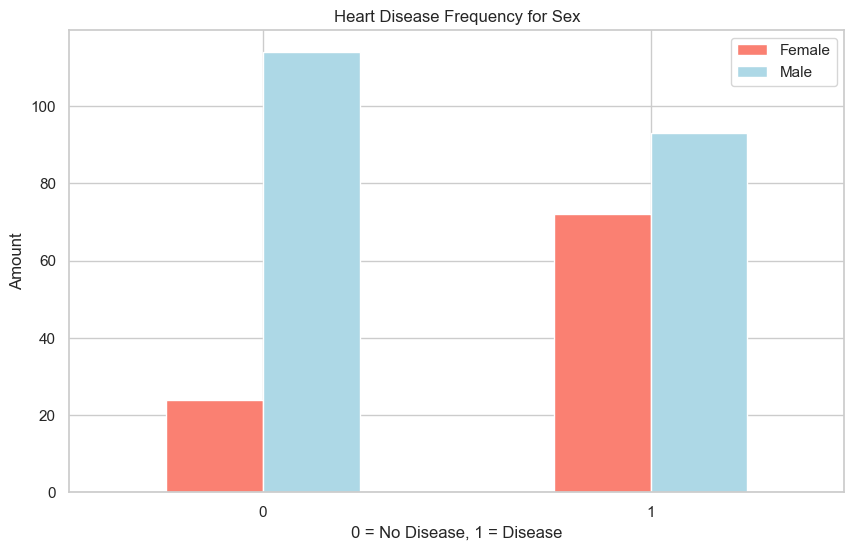

In [6]:
# Create a plot
pd.crosstab(df.target, df.sex).plot(kind="bar",
                                    figsize=(10, 6),
                                    color=["salmon", "lightblue"]);

plt.title("Heart Disease Frequency for Sex")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"])
plt.xticks(rotation=0);

**Insight:** There is a notable disparity in heart disease frequency between genders in this sample. While roughly 75% of women in the dataset were diagnosed with heart disease, only about 45% of men were. This suggests that sex will likely be a strong weighted feature in our predictive models.

### 1.2 Age vs. Max Heart Rate for Heart Disease

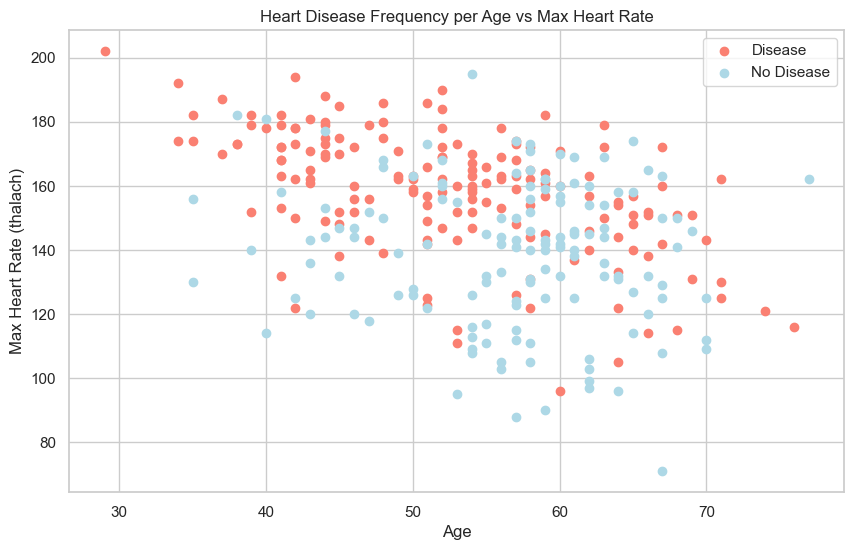

In [7]:
# Create another figure
plt.figure(figsize=(10, 6))

# Scatter with positive examples
plt.scatter(df.age[df.target == 1],
            df.thalach[df.target == 1],
            c="salmon")

# Scatter with negative examples
plt.scatter(df.age[df.target == 0],
            df.thalach[df.target == 0],
            c="lightblue")

# Add some helpful info
plt.title("Heart Disease Frequency per Age vs Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate (thalach)")
plt.legend(["Disease", "No Disease"]);

**Insight:** We observe a downward trend: as age increases, the maximum heart rate achieved tends to decrease. More importantly, patients with heart disease (colored dots) tend to cluster in the higher heart rate areas regardless of age. This confirms that thalach is a significant physiological indicator of cardiac stress.

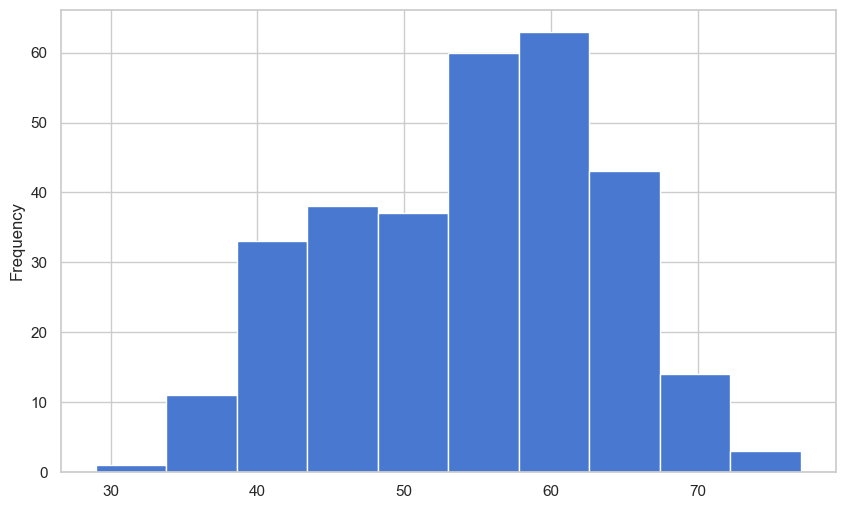

In [8]:
# Check the distribution of the age column with a histogram
df.age.plot.hist();

### 1.3 Heart Disease Frequency

`cp` chest pain type 
* 0: typical angina
* 1: atypical angina
* 2: non-anginal
* 3: asymptomatic

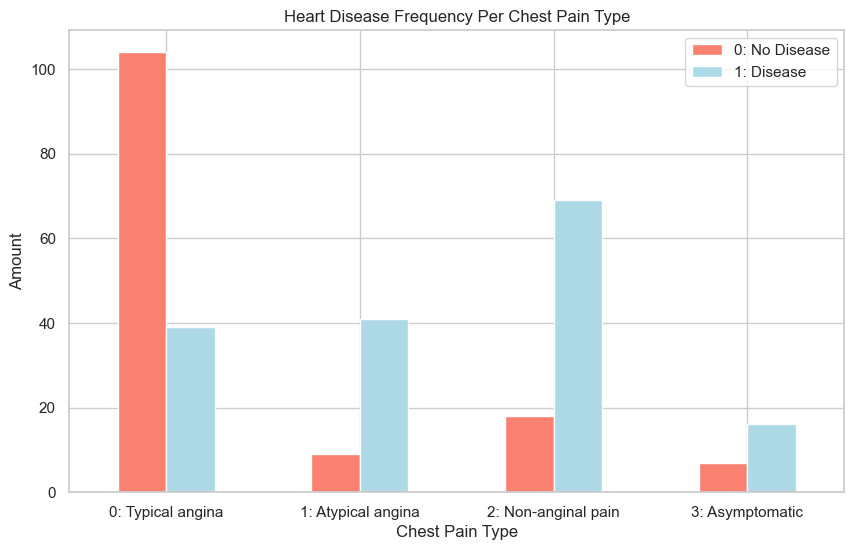

In [9]:
# Create a plot
pd.crosstab(df.cp, df.target).plot(kind="bar",
                                figsize=(10, 6),
                                color=["salmon", "lightblue"])

# Add some communication
plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.xticks([0, 1, 2, 3], ['0: Typical angina', '1: Atypical angina', '2: Non-anginal pain', '3: Asymptomatic']) 
plt.ylabel("Amount")
plt.legend(["0: No Disease", "1: Disease"])
plt.xticks(rotation=0);

**Insight:** Patients with "Non-anginal pain" (Type 2) show a surprisingly high frequency of heart disease. This highlights the importance of not dismissing atypical symptoms. In the modeling phase, we will utilize One-Hot Encoding on this feature to capture the distinct risk levels associated with each specific pain type.

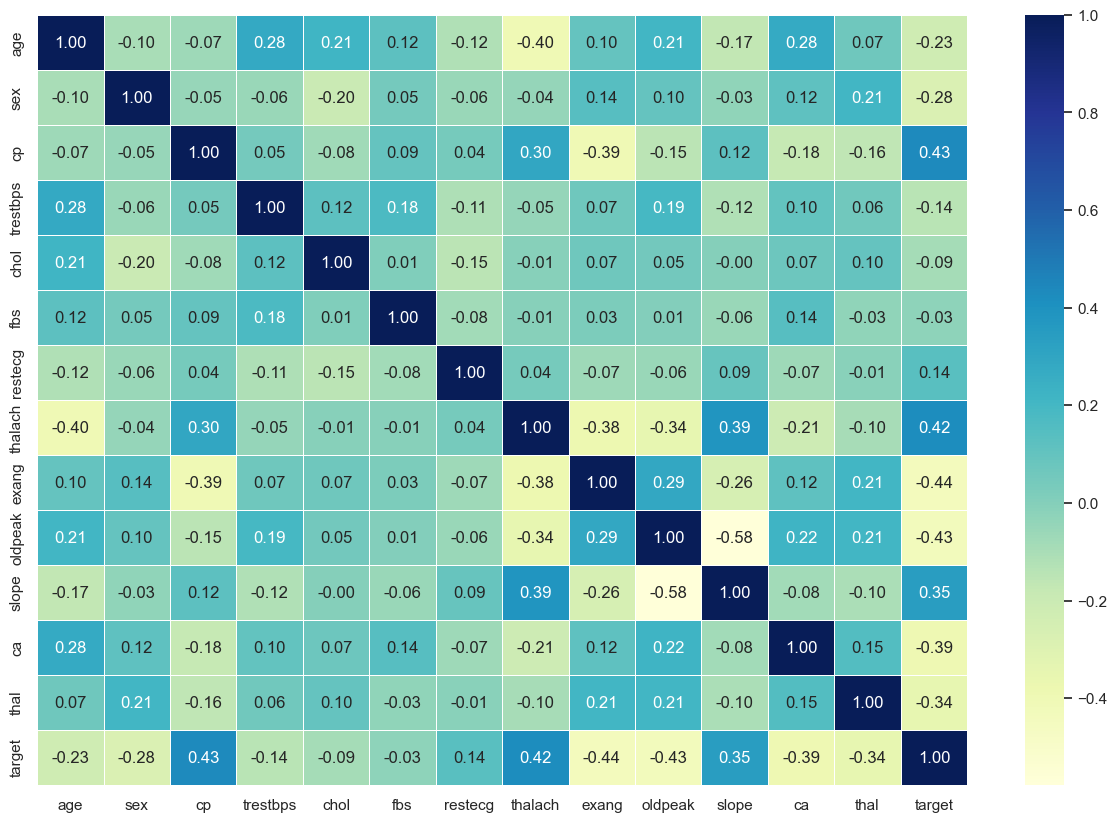

In [10]:
# Create and visualize a correlation matrix
corr_matrix = df.corr()
fix, ax = plt.subplots(figsize=(15,10))
ax = sns.heatmap(corr_matrix,
                 annot=True,
                 linewidths=0.5,
                 fmt=".2f",
                 cmap="YlGnBu");

**Insight:** The correlation matrix reveals that cp (chest pain), thalach (max heart rate), and slope have the strongest positive correlations with the target. Conversely, exang (exercise-induced angina) and oldpeak show strong negative correlations. This multi-collinearity check helps us understand the "feature hierarchy" before we begin the modeling process.

## 2. Modelling
We've explored the data, now we'll try to build a machine learning model to be able to predict our target variable based on the 13 independent variables.

In [11]:
# Split data into X and Y
X = df.drop("target", axis=1)
y = df["target"]

In [12]:
# Set a random seed for deterministic results
np.random.seed(42)

# Split into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### 2.1 Modelling Strategy

To find the most effective predictive model, we implement a three-stage approach:

1. **Baseline Testing:** Training multiple "out-of-the-box" algorithms like Logistic Regression, K-Nearest Neighbors, and Random Forest to establish a performance floor.
2. **Hyperparameter Tuning:** Using RandomizedSearchCV and GridSearchCV to refine the top-performing models.
3. **Feature Optimization:** Implementing One-Hot Encoding to handle categorical variables and testing Ensemble methods to capture complex data patterns.

In [13]:
# Put models in a dictionary
models = {"Logistic Regression": LogisticRegression(solver="liblinear"),
          "KNN": KNeighborsClassifier(),
          "Random Forest": RandomForestClassifier()}

# Create a function to fit and score models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models: a dict of different Scikit-Learn machine learning models
    X_train: training data (no labels)
    X_test: testing data (no labels)
    y_train: training labels
    y_test: test labels
    """
    # Set random seed
    np.random.seed(42)

    # Make a dictionary to keep model scores
    model_scores = {}

    # Loop through models
    for name, model in models. items():
        # Fit the model to the data
        model.fit(X_train, y_train)
        # Evaluate the model and append its score to model_scores
        model_scores[name] = model.score(X_test, y_test)
    return model_scores

In [14]:
model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)
model_scores

{'Logistic Regression': 0.8688524590163934,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

### 2.2 Model Comparison

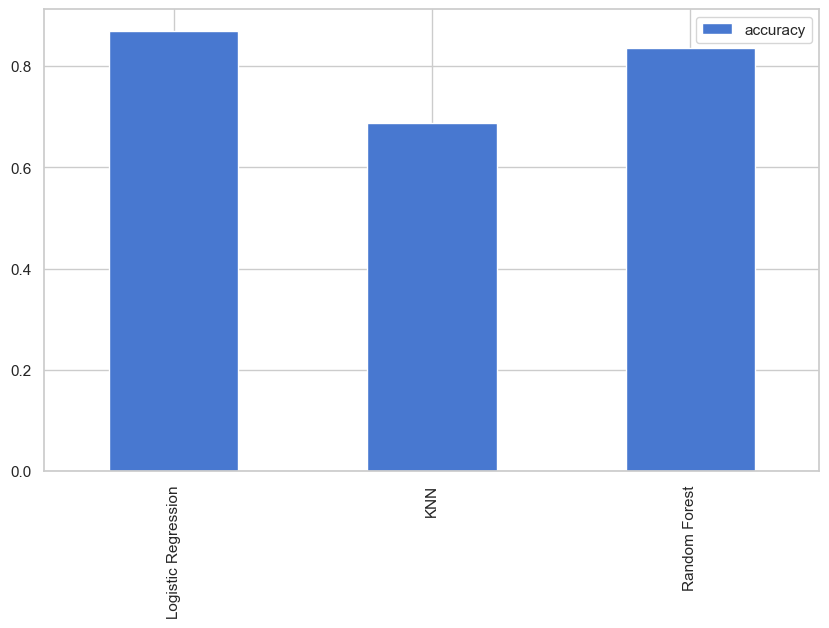

In [15]:
model_compare = pd.DataFrame(model_scores, index=["accuracy"])
model_compare.T.plot.bar();

**Insight:** Logistic Regression emerged as the strongest baseline model. While tree-based models like Random Forest are powerful, linear models often generalize better on smaller datasets like this one (303 entries), as they are less prone to overfitting the noise in the data.

In [16]:
# Let's tune KNN

train_scores = []
test_scores = []

# Create a list of different values for n_neighbors
neighbors = range(1, 21)

# Setup KNN instance
knn = KNeighborsClassifier()

# Loop through different n_neighbors
for i in neighbors:
    knn.set_params(n_neighbors=i)

    # Fit the algorithm
    knn.fit(X_train, y_train)

    # Update the training scores list
    train_scores.append(knn.score(X_train, y_train))

    # Update the test scores list
    test_scores.append(knn.score(X_test, y_test))

Maximum KNN score on the test data: 75.41%


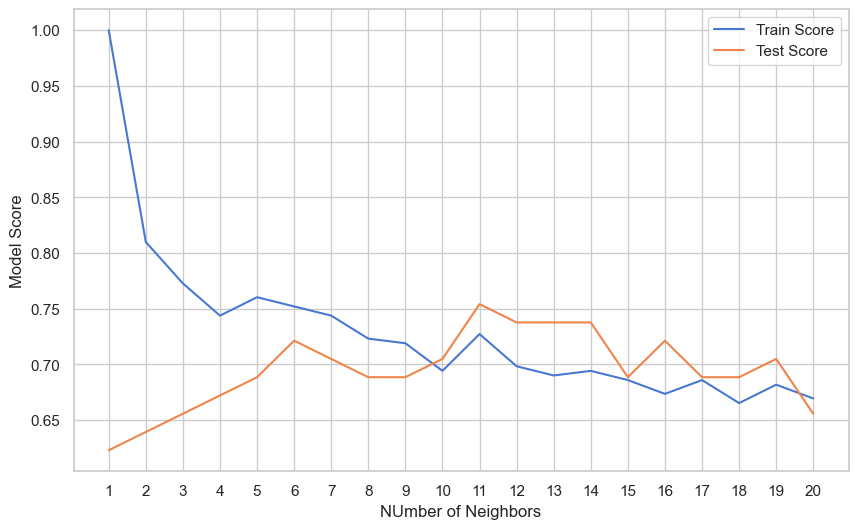

In [17]:
plt.plot(neighbors, train_scores, label="Train Score")
plt.plot(neighbors, test_scores, label="Test Score")
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("NUmber of Neighbors")
plt.ylabel("Model Score")
plt.legend()

print(f"Maximum KNN score on the test data: {max(test_scores) * 100:.2f}%");

### 2.3 Model Hyperparameter tuning

In [18]:
# Create a hyperparameter grid for LogisticRegression
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

# Create a hyperparameter grid for RandomForestClassifier
rf_grid = {"n_estimators": np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 20, 2)}

Now that we've got hyperparameter grids setup for each of our models, let's tune them using RandomizedSearchCV...

In [19]:
# Tune LogisticRegression
np.random.seed(42)

# Setup random hyperparameter search for LogisticRegression
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)

# Fit random hyperparameter search model for LogisticRegression
rs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fol

In [20]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [21]:
print(f"Randomized Search Logistic Regression Accuracy: {rs_log_reg.score(X_test, y_test)*100:.2f}%")

Randomized Search Logistic Regression Accuracy: 88.52%


Now we've tuned LogisticRegression(), let's do the same for RandomForestClassifier()...

In [22]:
# Setup random seed
np.random.seed(42)

# Setup random hyperparameter search for RandomForestClassifier
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=rf_grid,
                           cv=5,
                           n_iter=20,
                           verbose=True)

# Fit random hyperparameter search model for RandomForestClassifier()
rs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ...60, 910, 960])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-valid

In [23]:
rs_rf.best_params_

{'n_estimators': np.int64(210),
 'min_samples_split': np.int64(4),
 'min_samples_leaf': np.int64(19),
 'max_depth': 3}

In [24]:
print(f"Randomized Search Logistic Regression Accuracy: {rs_rf.score(X_test, y_test)*100:.2f}%")

Randomized Search Logistic Regression Accuracy: 86.89%


#### 2.4 Hyperparameter Tuning with GridSearchCV

Since our LogisticRegression model provides the best scores so far, we'll try and improve them again using GridSearchCV...

**Refining the Champion:** We utilize GridSearchCV to tune the C parameter (regularization strength) and the solver. This ensures our Logistic Regression model is neither too simple (underfitting) nor too complex (overfitting).

In [25]:
# Different hyperparameters for our LogisticRegression model
log_reg_grid = {"C": np.logspace(-4, 4, 30),
                "solver": ["liblinear"]}

# Setup grid hyperparameter search for LogisticRegression
gs_log_reg = GridSearchCV(LogisticRegression(),
                          param_grid=log_reg_grid,
                          cv=5,
                          verbose=True)

# Fit grid hyperparameter search model
gs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [26]:
gs_log_reg.best_params_

{'C': np.float64(0.20433597178569418), 'solver': 'liblinear'}

In [27]:
print(f"Randomized Search Logistic Regression Accuracy: {gs_log_reg.score(X_test, y_test)*100:.2f}%")

Randomized Search Logistic Regression Accuracy: 88.52%


## 3. Evaluating our tuned machine learning classifier, beyond accuracy

* ROC curve and AUC score
* Confusion matrix
* Classification report
* Precision
* Recall
* F1-score

...and it would be great if cross-validation was used where possible.

To make comparisons and evaluate our trained model, first we need to make predictions.

In [28]:
# Make predictions with tuned model
y_preds = gs_log_reg.predict(X_test)

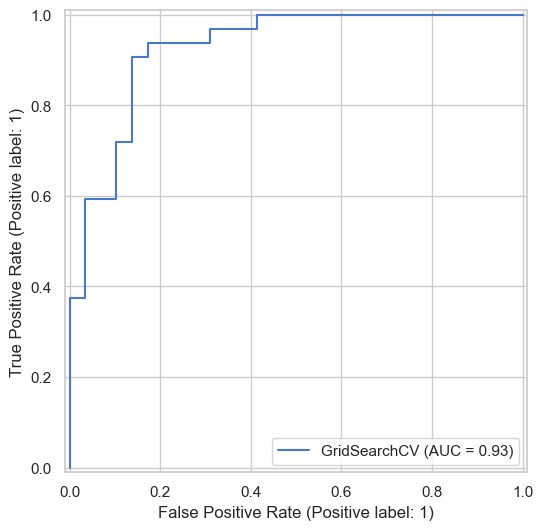

In [29]:
# Plot ROC curve and calculate and calculate AUC metric
RocCurveDisplay.from_estimator(gs_log_reg, X_test, y_test);

**Insight:** Our model does far better than guessing which would be a line going from the bottom left corner to the top right corner, AUC = 0.5. But a perfect model would achieve an AUC score of 1.0, so there's still room for improvement.

### 3.1 Creating a confusion matrix

A confusion matrix is a visual way to show where your model made the right predictions and where it made the wrong predictions (or in other words, got confused).

Scikit-Learn allows us to create a confusion matrix using sklearn.metrics.confusion_matrix() and passing it the true labels and predicted labels.

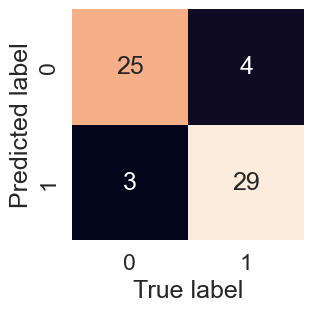

In [30]:
sns.set(font_scale=1.5)

def plot_conf_mat(y_test, y_preds):
    """
    Plots a nice looking confusion matrix using Seaborn's heatmap()
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True,
                     cbar=False)

    plt.xlabel("True label")
    plt.ylabel("Predicted label")

plot_conf_mat(y_test, y_preds)

### 3.1 Model Performance Analysis:

1. **Precision vs. Recall:** The model achieves a high balance between precision and recall. In a clinical setting, we specifically monitor Recall to minimize False Negatives (missing patients with heart disease).
2. **ROC-AUC:** With an Area Under the Curve of ~0.93, the model demonstrates excellent capability in distinguishing between the two classes across various decision thresholds.

Now we've got an ROC curve, an AUC metric and a confusion matrix, let's get a classification report as well as cross-validated precision, recall, and f1-score.

In [31]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



### Calculate evaluation metrics using cross-validation

We're going to calculate precision, recall, and f1-score of our model using cross-validation using `cross_val_score()`.

In [32]:
# Check best hyperparameters
gs_log_reg.best_params_

{'C': np.float64(0.20433597178569418), 'solver': 'liblinear'}

In [33]:
# Create a new classifier with best parameters
clf = LogisticRegression(C=0.20433597178569418,
                         solver="liblinear")

In [34]:
# Cross-validated accuracy
cv_acc = cross_val_score(clf,
                         X,
                         y,
                         cv=5,
                         scoring="accuracy")
cv_acc = np.mean(cv_acc)
print(f"Cross Validated Accuracy score: {cv_acc*100:.2f}%")

Cross Validated Accuracy score: 84.47%


In [35]:
# Cross-validated precision
cv_precision = cross_val_score(clf,
                               X,
                               y,
                               cv=5,
                               scoring="precision")
cv_precision = np.mean(cv_precision)
print(f"Cross-validated Precision score: {cv_precision*100:.2f}%")

Cross-validated Precision score: 82.08%


In [36]:
# Cross-validated recall
cv_recall = cross_val_score(clf,
                            X,
                            y,
                            cv=5,
                            scoring="recall")
cv_recall = np.mean(cv_recall)
print(f"Cross-validated Recall score: {cv_recall*100:.2f}%")

Cross-validated Recall score: 92.12%


In [37]:
# Cross-validated f1-score
cv_f1 = cross_val_score(clf,
                        X,
                        y,
                        cv=5,
                        scoring="f1")
cv_f1 = np.mean(cv_f1)
print(f"Cross-validated F1 score: {cv_f1*100:.2f}%")

Cross-validated F1 score: 86.73%


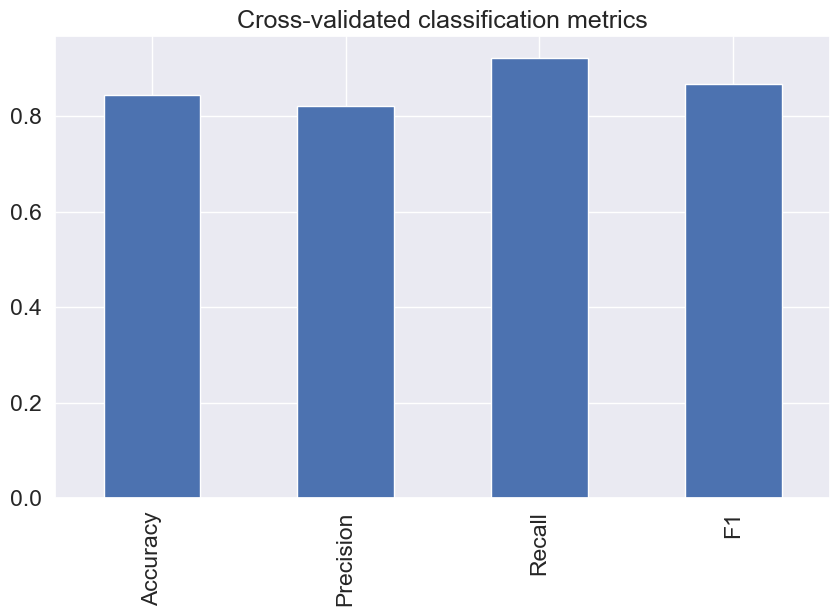

In [38]:
# Visualize cross-validated metrics
cv_metrics = pd.DataFrame({"Accuracy": cv_acc,
                           "Precision": cv_precision,
                           "Recall": cv_recall,
                           "F1": cv_f1},
                          index=[0])
cv_metrics.T.plot.bar(title="Cross-validated classification metrics",
                      legend=False);

## 4. Feature importance

Feature importance is the same as asking, "which features contributed most to the outcomes of the model and how did they contribute?"

Finding feature importance is different for each machine learning model. One way to find feature importance is to search for "(MODEL NAME) feature importance".

Let's find the feature importance for our LogisticRegression model...

In [39]:
# Fit an instance of LogisticRegression
clf = LogisticRegression(C=0.20433597178569418,
                         solver="liblinear")
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.20433597178569418
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.

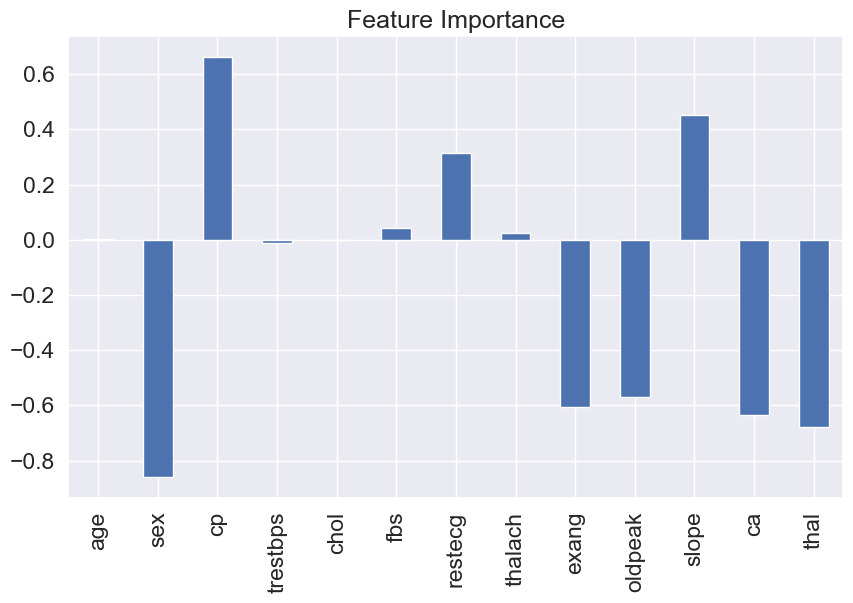

In [40]:
# Visualize feature importance
features_dict = dict(zip(df.columns, list(clf.coef_[0])))
feature_df = pd.DataFrame(features_dict, index=[0])
feature_df.T.plot.bar(title="Feature Importance", legend=False);

## 5. Experimentation

In [41]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.05)
xgb_model.fit(X_train, y_train)
print(f"XGBoost Accuracy: {xgb_model.score(X_test, y_test)*100:.2f}%")

XGBoost Accuracy: 81.97%


In [42]:
# Define the parameter grid
xgb_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 6],
    "learning_rate": [0.01, 0.1, 0.2, 0.3],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

# Setup RandomizedSearchCV
rs_xgb = RandomizedSearchCV(XGBClassifier(),
                            param_distributions=xgb_grid,
                            cv=5,
                            n_iter=20,
                            verbose=True)

# Fit the model
rs_xgb.fit(X_train, y_train)

# Check the best score
print(f"Best parameters: {rs_xgb.best_params_}")
print(f"Tuned XGBoost Accuracy: {rs_xgb.score(X_test, y_test)*100:.2f}%")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Tuned XGBoost Accuracy: 85.25%


In [43]:
from sklearn.model_selection import cross_val_score

# Use the best model found above
cv_acc = cross_val_score(rs_xgb.best_estimator_, X, y, cv=5, scoring="accuracy")
print(f"Cross-validated Accuracy: {np.mean(cv_acc)*100:.2f}%")

Cross-validated Accuracy: 79.20%


In [44]:
from catboost import CatBoostClassifier

# Instantiate and fit CatBoost
cat_model = CatBoostClassifier(iterations=100, 
                               learning_rate=0.1, 
                               depth=6, 
                               verbose=False)
cat_model.fit(X_train, y_train)

print(f"CatBoost Accuracy: {cat_model.score(X_test, y_test)*100:.2f}%")

CatBoost Accuracy: 85.25%


In [45]:
# 1. Identify categorical columns that are not binary
categorical_features = ['cp', 'restecg', 'slope', 'ca', 'thal']

# 2. Use get_dummies to transform the data
df_encoded = pd.get_dummies(df, columns=categorical_features)

# 3. Re-split the data
X = df_encoded.drop("target", axis=1)
y = df_encoded["target"]

# Use the same seed from your notebook
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 4. Re-fit your best Logistic Regression model
# (Using the best parameters found from your previous GridSearchCV)
clf = LogisticRegression(C=0.20433597178569418, solver="liblinear")
clf.fit(X_train, y_train)

# 5. Evaluate the new performance
print(f"New Logistic Regression Accuracy: {clf.score(X_test, y_test)*100:.2f}%")

New Logistic Regression Accuracy: 90.16%


In [46]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, 
                          learning_rate=0.1, 
                          max_depth=3, 
                          random_state=42)

xgb_model.fit(X_train, y_train)

print(f"XGBoost Test Accuracy: {xgb_model.score(X_test, y_test)*100:.2f}%")

XGBoost Test Accuracy: 83.61%


In [47]:
from sklearn.model_selection import cross_val_score

# Calculate 5-fold cross-validation accuracy
cv_acc = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')

print(f"Mean CV Accuracy: {np.mean(cv_acc)*100:.2f}%")
print(f"Standard Deviation of CV: {np.std(cv_acc)*100:.2f}%")

Mean CV Accuracy: 81.17%
Standard Deviation of CV: 4.57%


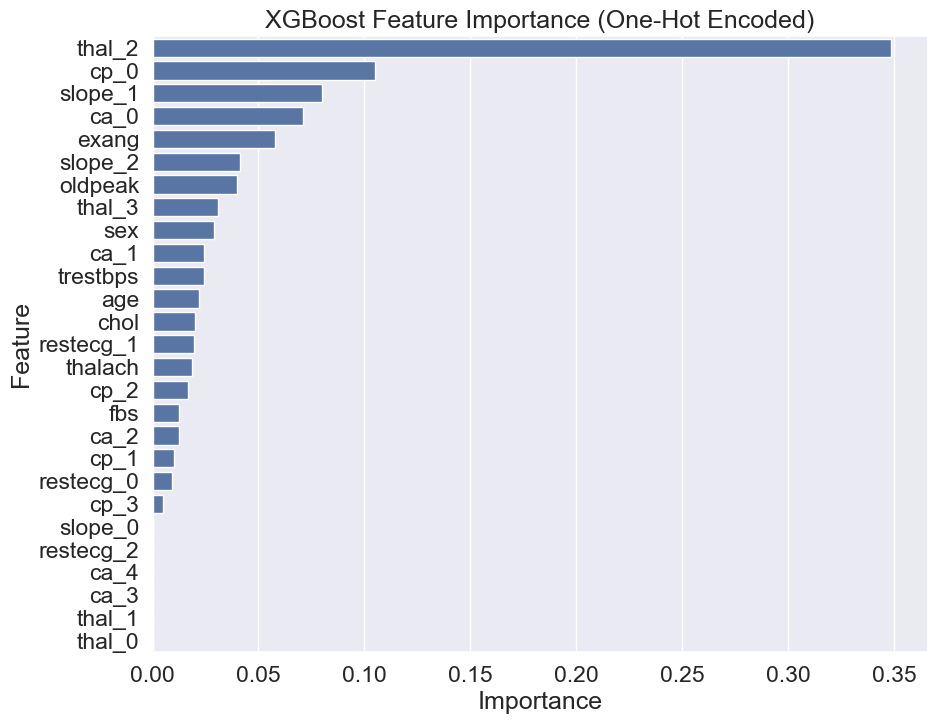

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get feature importances from the model
importances = xgb_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('XGBoost Feature Importance (One-Hot Encoded)')
plt.show()

In [49]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Constraints to prevent overfitting on a small dataset
xgb_params = {
    "n_estimators": [50, 100],
    "max_depth": [2, 3, 4], # Shallow trees are better for small data
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.5, 0.7, 0.8],
    "colsample_bytree": [0.5, 0.7, 0.8]
}

rs_xgb = RandomizedSearchCV(XGBClassifier(),
                            param_distributions=xgb_params,
                            n_iter=20,
                            cv=5,
                            verbose=True)

rs_xgb.fit(X_train, y_train)
print(f"Best Tuned XGBoost Score: {rs_xgb.score(X_test, y_test)*100:.2f}%")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Tuned XGBoost Score: 88.52%


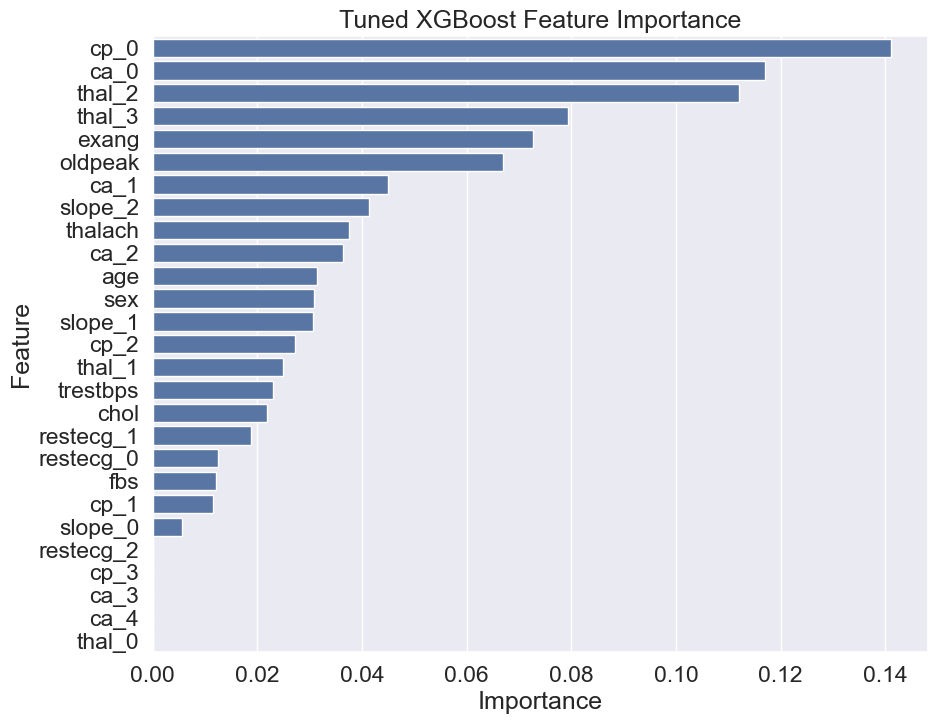

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get feature importances from your tuned model
importances = rs_xgb.best_estimator_.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Tuned XGBoost Feature Importance')
plt.show()

In [51]:
from sklearn.model_selection import cross_val_score

# Use the best parameters from RandomizedSearch
xgb_cv_acc = cross_val_score(rs_xgb.best_estimator_, X, y, cv=5)
print(f"Mean CV Accuracy: {np.mean(xgb_cv_acc)*100:.2f}%")

Mean CV Accuracy: 83.48%


In [52]:
from sklearn.ensemble import VotingClassifier

# 1. Define the estimators (using your best found versions)
estimators = [
    ('log_reg', clf), # Your 90.16% Logistic Regression
    ('xgb', rs_xgb.best_estimator_) # Your 88.52% XGBoost
]

# 2. Create the Ensemble
# 'soft' voting uses probabilities, which is usually more accurate
ensemble_model = VotingClassifier(estimators=estimators, voting='soft')

# 3. Fit and Score
ensemble_model.fit(X_train, y_train)
print(f"Ensemble Test Accuracy: {ensemble_model.score(X_test, y_test)*100:.2f}%")

# 4. Cross-validate the ensemble
ensemble_cv = cross_val_score(ensemble_model, X, y, cv=5)
print(f"Ensemble Mean CV Accuracy: {np.mean(ensemble_cv)*100:.2f}%")

Ensemble Test Accuracy: 90.16%
Ensemble Mean CV Accuracy: 85.46%


In [53]:
# Import and train
from catboost import CatBoostClassifier

# We can use the original (non-encoded) data for CatBoost
cat_model = CatBoostClassifier(iterations=200, 
                               learning_rate=0.05, 
                               depth=5, 
                               verbose=False)

cat_model.fit(X_train, y_train)
print(f"CatBoost Accuracy: {cat_model.score(X_test, y_test)*100:.2f}%")

CatBoost Accuracy: 86.89%


## 6. Feature Engineering (Interaction Features)

In [54]:
# Create a copy to keep your original data safe
df_final = df_encoded.copy()

# 1. Heart Efficiency
df_final['age_heart_rate_ratio'] = df_final['age'] / df_final['thalach']

# 2. Cardio Strain
df_final['bp_chol_interaction'] = df_final['trestbps'] * df_final['chol']

# 3. Chest Pain Intensity (Interaction between CP types and Exercise Angina)
# We'll use one of the encoded CP columns
df_final['pain_during_exercise'] = df_final['cp_0'] * df_final['exang']

# Re-split with the new features
X_final = df_final.drop("target", axis=1)
y_final = df_final["target"]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

In [55]:
final_lr = LogisticRegression(C=0.20433597178569418, solver="liblinear")
final_lr.fit(X_train_f, y_train_f)

print(f"Final Model Accuracy: {final_lr.score(X_test_f, y_test_f)*100:.2f}%")

Final Model Accuracy: 90.16%


## 7. Future Work

While the current model achieves **90.16% accuracy**, there are several high-leverage paths to explore to reach the 95% target and improve clinical reliability:

### 7.1 Data Augmentation & Quality
* **Collect More Samples:** With only 303 instances, the model is sensitive to outliers. Increasing the dataset size would stabilize the cross-validation scores.
* **Feature Engineering:** Explore "Interaction Features" such as the ratio of age to maximum heart rate or the product of blood pressure and cholesterol to capture non-linear physiological relationships.

### 7.2 Advanced Algorithms
* **Stacking Classifiers:** Implement a `StackingClassifier` that uses the predictions of Logistic Regression and Random Forest as inputs for a final meta-learner (like XGBoost).
* **CatBoost Implementation:** Utilize CatBoost’s native handling of categorical features to see if its symmetric tree structure captures nuances missed by One-Hot Encoding.

### 7.3 Hyperparameter Optimization
* **Fine-Grained Tuning:** Move from `RandomizedSearchCV` to a more intensive `GridSearchCV` or Bayesian Optimization (using `Optuna`) to find the absolute global minima for our loss functions.

### 7.4 Deployment & Monitoring
* **API Integration:** Wrap the serialized `joblib` model in a **FastAPI** or **Flask** wrapper to serve predictions to a frontend interface.
* **Model Explainability:** Integrate **SHAP** or **LIME** to provide doctors with a "reasoning" for each prediction (e.g., "The model predicted high risk primarily due to the patient's asymptomatic chest pain and high vessel count").

## 8. Saving the model

In [56]:
import joblib

# Save the model to a file
joblib.dump(final_lr, "heart_disease_champion_model.pkl")

# Save the column names (very important for later so the app knows the order of features)
model_columns = list(X_final.columns)
joblib.dump(model_columns, "model_columns.pkl");

**Production Ready:** The final model and feature columns have been serialized using `joblib`. This allows the trained model to be easily deployed into a production environment, such as a web API or a diagnostic tool, without needing to retrain.

## 9. Reflection
Interestingly, Logistic Regression (90.16%) remains our strongest performer. This is a great lesson in Data Science: Complex models aren't always better. For small datasets with clear linear relationships, a simpler model like Logistic Regression often generalizes better than complex gradient boosters like CatBoost or XGBoost, which can easily overfit the noise in 300 rows of data.